# Notebook 2 — Exploratory Data Analysis (EDA)
**Sensor:** TI IWR6843ISK (77 GHz)  
**Dataset:** Single Activity Data — Sitting · Standing · Waiving · Walking  

### Contents
1. Setup & dataset inventory  
2. Frame & point-count statistics  
3. Doppler distribution per class  
4. Spatial footprint analysis (X-Y bounding box / spread)  
5. Range-Doppler energy analysis  
6. SNR & noise floor analysis  
7. Per-frame feature engineering & correlation  
8. PCA / t-SNE class separability  
9. Cross-distance distribution shift  
10. Outlier / anomaly detection  
11. Summary — key findings  

In [1]:
# ── 1. Setup ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.0)

DATA_ROOT = Path('Data/Research Data/Single Activity Data')
ACTIVITIES  = ['Sitting', 'Standing', 'Waiving', 'Walking']
DISTANCES   = ['1m', '2m', '2.5', '3m', '4.m']
TRAIN_DISTS = ['1m', '2m', '2.5']
TEST_DISTS  = ['3m', '4.m']
DIST_LABEL  = {'1m': '1 m', '2m': '2 m', '2.5': '2.5 m', '3m': '3 m', '4.m': '4 m'}

ACT_PAL = dict(zip(ACTIVITIES, sns.color_palette('tab10', len(ACTIVITIES))))
print('Setup done.')

Setup done.


In [2]:
# ── Data loading helpers ───────────────────────────────────────────────────────
def load_pc(act, dist):
    df = pd.read_csv(DATA_ROOT / act / dist / 'points_cloud.csv')
    df.columns = df.columns.str.strip()
    df['activity'] = act
    df['distance'] = dist
    return df

def load_rd(act, dist):
    df = pd.read_csv(DATA_ROOT / act / dist / 'range_doppler.csv')
    df.columns = df.columns.str.strip()
    df['activity'] = act
    df['distance'] = dist
    return df

def load_snr(act, dist):
    df = pd.read_csv(DATA_ROOT / act / dist / 'noise_snr.csv')
    df.columns = df.columns.str.strip()
    df['activity'] = act
    df['distance'] = dist
    return df

# Load all data into combined DataFrames
all_pc  = pd.concat([load_pc(a, d)  for a in ACTIVITIES for d in DISTANCES], ignore_index=True)
all_rd  = pd.concat([load_rd(a, d)  for a in ACTIVITIES for d in DISTANCES], ignore_index=True)
all_snr = pd.concat([load_snr(a, d) for a in ACTIVITIES for d in DISTANCES], ignore_index=True)

print(f'Point cloud rows : {len(all_pc):,}')
print(f'Range-Doppler rows: {len(all_rd):,}')
print(f'SNR rows         : {len(all_snr):,}')

Point cloud rows : 3,238
Range-Doppler rows: 6,406,144
SNR rows         : 3,238


## 1. Dataset Inventory

In [3]:
rows = []
for act in ACTIVITIES:
    for dist in DISTANCES:
        pc  = load_pc(act, dist)
        rd  = load_rd(act, dist)
        snr = load_snr(act, dist)
        rows.append({
            'Activity': act,
            'Distance': DIST_LABEL[dist],
            'Split': 'Train' if dist in TRAIN_DISTS else 'Test',
            'PC frames': pc['frame_number'].nunique(),
            'RD frames': rd['frame_number'].nunique(),
            'Total points': len(pc),
            'Avg pts/frame': round(pc.groupby('frame_number').size().mean(), 1),
            'R-D r_bins': int(rd['range_bin'].max()) + 1,
            'R-D d_bins': int(rd['doppler_bin'].max()) + 1,
        })

inventory = pd.DataFrame(rows)
print(inventory.to_string(index=False))

Activity Distance Split  PC frames  RD frames  Total points  Avg pts/frame  R-D r_bins  R-D d_bins
 Sitting      1 m Train         34         27           115            3.4          64         128
 Sitting      2 m Train         36         36            54            1.5          64         128
 Sitting    2.5 m Train         26         26            56            2.2          64         128
 Sitting      3 m  Test         40         40            72            1.8          64         128
 Sitting      4 m  Test         41         41            54            1.3          64         128
Standing      1 m Train         42         43            64            1.5          64         128
Standing      2 m Train         48         48           158            3.3          64         128
Standing    2.5 m Train         43         43            79            1.8          64         128
Standing      3 m  Test         42         42            79            1.9          64         128
Standing  

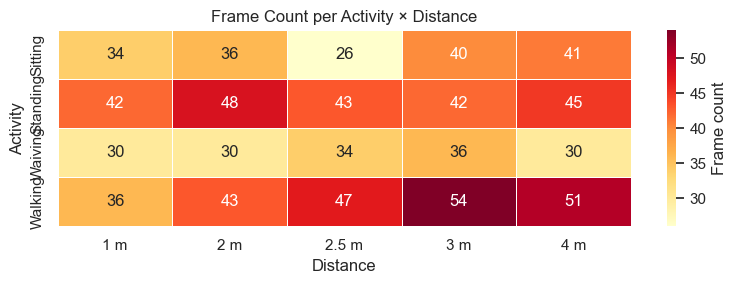

In [4]:
# Frame count heatmap
pivot = inventory.pivot(index='Activity', columns='Distance', values='PC frames')
fig, ax = plt.subplots(figsize=(8, 3))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Frame count'}, ax=ax)
ax.set_title('Frame Count per Activity × Distance', fontsize=12)
plt.tight_layout()
plt.savefig('eda_frame_count_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## 2. Frame & Point-Count Statistics

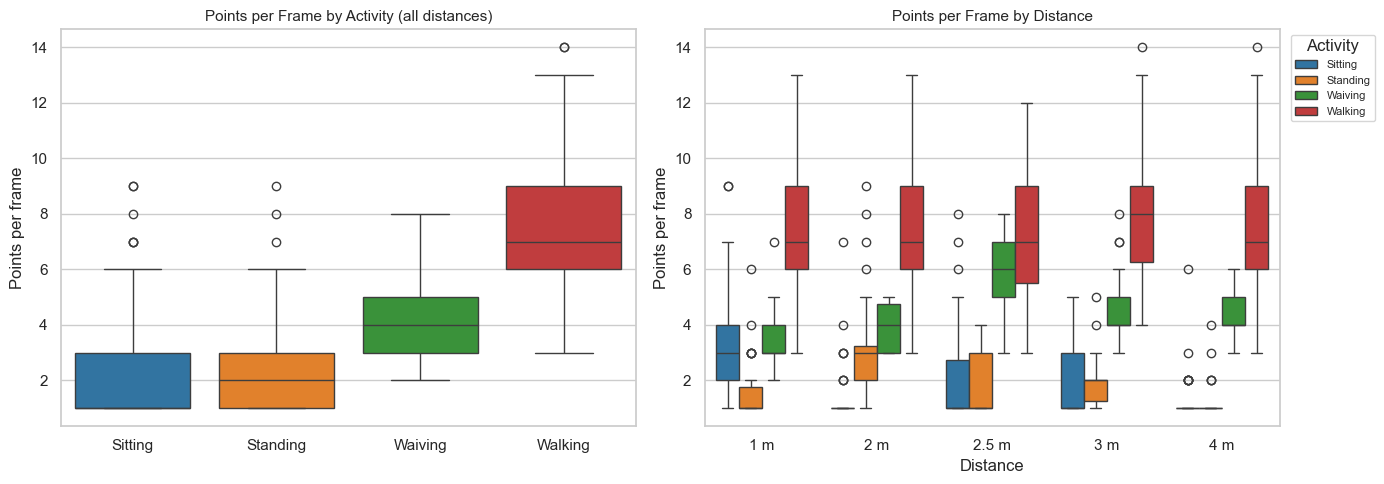


Summary statistics — points per frame:
          count  mean   std  min  25%  50%  75%   max
activity                                             
Sitting   177.0  1.98  1.63  1.0  1.0  1.0  3.0   9.0
Standing  220.0  1.97  1.29  1.0  1.0  2.0  3.0   9.0
Waiving   160.0  4.45  1.30  2.0  3.0  4.0  5.0   8.0
Walking   231.0  7.54  2.32  3.0  6.0  7.0  9.0  14.0


In [5]:
# Points-per-frame box plots per activity (all distances pooled)
ppf_rows = []
for act in ACTIVITIES:
    for dist in DISTANCES:
        pc  = load_pc(act, dist)
        ppf = pc.groupby('frame_number').size().reset_index(name='pts_per_frame')
        ppf['activity'] = act
        ppf['distance'] = DIST_LABEL[dist]
        ppf_rows.append(ppf)
ppf_df = pd.concat(ppf_rows, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot by activity
sns.boxplot(data=ppf_df, x='activity', y='pts_per_frame',
            palette=ACT_PAL, ax=axes[0])
axes[0].set_title('Points per Frame by Activity (all distances)', fontsize=11)
axes[0].set_xlabel(''); axes[0].set_ylabel('Points per frame')

# Box plot by distance
sns.boxplot(data=ppf_df, x='distance', y='pts_per_frame',
            hue='activity', palette=ACT_PAL, ax=axes[1])
axes[1].set_title('Points per Frame by Distance', fontsize=11)
axes[1].set_xlabel('Distance'); axes[1].set_ylabel('Points per frame')
axes[1].legend(title='Activity', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('eda_pts_per_frame.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nSummary statistics — points per frame:')
print(ppf_df.groupby('activity')['pts_per_frame'].describe().round(2))

## 3. Doppler Velocity Distribution per Class

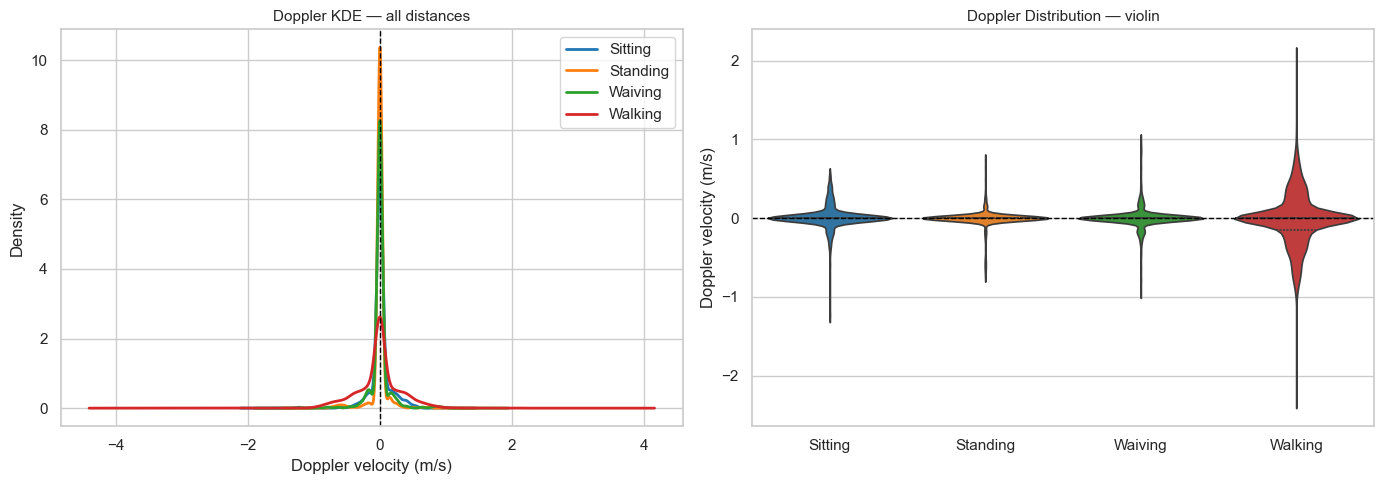


Doppler summary by activity:
           count   mean    std    min    25%  50%  75%    max
activity                                                     
Sitting    351.0  0.012  0.146 -1.230  0.000  0.0  0.0  0.541
Standing   433.0 -0.005  0.117 -0.738  0.000  0.0  0.0  0.738
Waiving    712.0  0.003  0.146 -0.935  0.000  0.0  0.0  0.984
Walking   1742.0 -0.017  0.332 -2.264 -0.148  0.0  0.0  2.018


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE overlay — all distances pooled
for act in ACTIVITIES:
    dop = all_pc[all_pc['activity'] == act]['doppler']
    dop.plot.kde(ax=axes[0], label=act, color=ACT_PAL[act], linewidth=2)
axes[0].axvline(0, color='black', linewidth=1, linestyle='--')
axes[0].set_title('Doppler KDE — all distances', fontsize=11)
axes[0].set_xlabel('Doppler velocity (m/s)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Violin plot
sns.violinplot(data=all_pc, x='activity', y='doppler',
               palette=ACT_PAL, inner='quartile', ax=axes[1])
axes[1].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1].set_title('Doppler Distribution — violin', fontsize=11)
axes[1].set_xlabel('')
axes[1].set_ylabel('Doppler velocity (m/s)')

plt.tight_layout()
plt.savefig('eda_doppler_dist.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nDoppler summary by activity:')
print(all_pc.groupby('activity')['doppler'].describe().round(3))

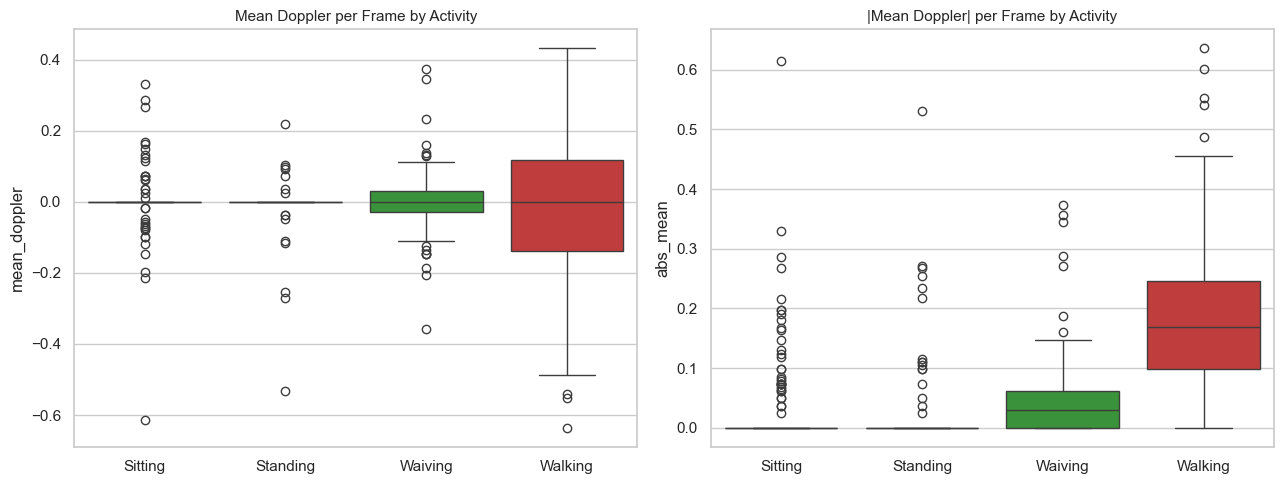

In [7]:
# Per-class mean Doppler per frame (all distances)
frame_dop = all_pc.groupby(['activity', 'distance', 'frame_number'])['doppler'].agg(
    mean_doppler='mean', std_doppler='std', abs_mean=lambda x: x.abs().mean()
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=frame_dop, x='activity', y='mean_doppler',
            palette=ACT_PAL, ax=axes[0])
axes[0].set_title('Mean Doppler per Frame by Activity', fontsize=11)
axes[0].set_xlabel('')

sns.boxplot(data=frame_dop, x='activity', y='abs_mean',
            palette=ACT_PAL, ax=axes[1])
axes[1].set_title('|Mean Doppler| per Frame by Activity', fontsize=11)
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig('eda_mean_doppler_per_frame.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Spatial Footprint Analysis

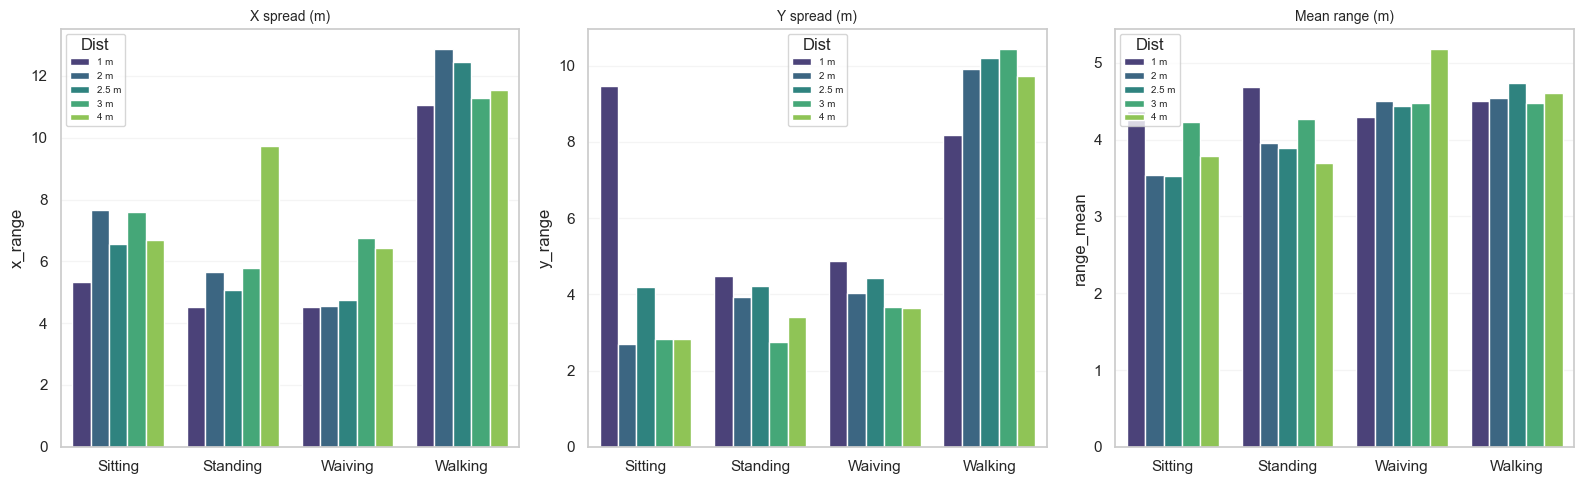

In [8]:
# Compute per-recording spatial stats
spatial_rows = []
for act in ACTIVITIES:
    for dist in DISTANCES:
        pc = load_pc(act, dist)
        spatial_rows.append({
            'Activity': act,
            'Distance': DIST_LABEL[dist],
            'x_range': pc['x'].max() - pc['x'].min(),
            'y_range': pc['y'].max() - pc['y'].min(),
            'z_range': pc['z'].max() - pc['z'].min(),
            'x_std': pc['x'].std(),
            'y_std': pc['y'].std(),
            'range_mean': pc['range'].mean(),
            'range_std': pc['range'].std(),
        })
spatial_df = pd.DataFrame(spatial_rows)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, title in zip(axes,
                          ['x_range', 'y_range', 'range_mean'],
                          ['X spread (m)', 'Y spread (m)', 'Mean range (m)']):
    sns.barplot(data=spatial_df, x='Activity', y=col, hue='Distance',
                ax=ax, palette='viridis')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('')
    ax.legend(title='Dist', fontsize=7)
    ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('eda_spatial_footprint.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Range-Doppler Energy Analysis

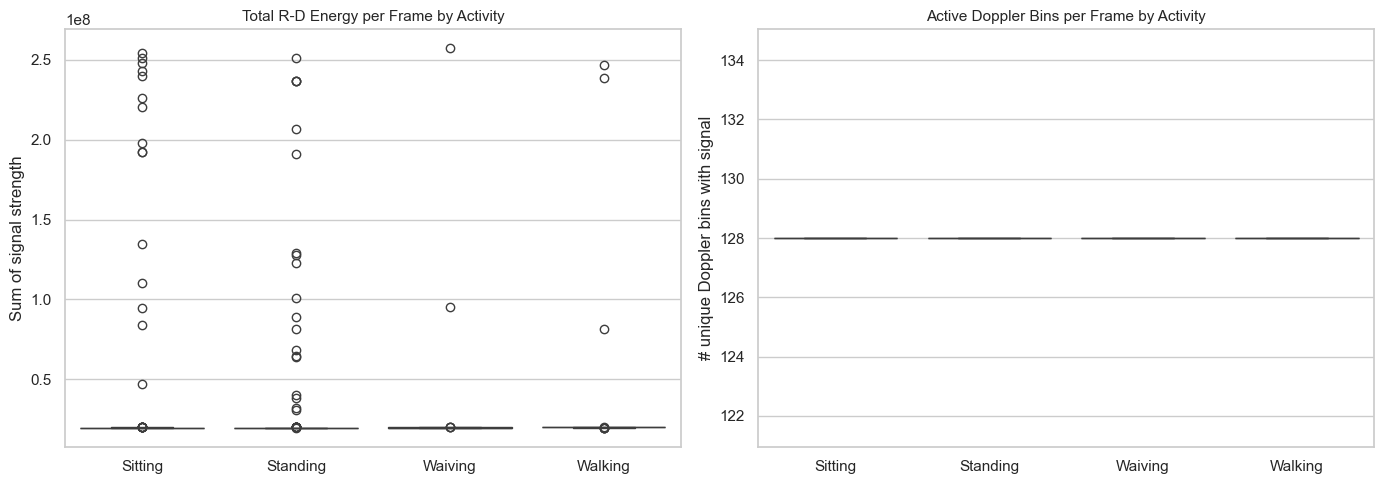


Energy summary by activity:
          count      mean       std       min       25%       50%       75%  \
activity                                                                      
Sitting     170  34049443  50494255  19609433  19641012  19658754  19725479   
Standing    221  28616622  36855954  19611964  19645956  19666220  19697242   
Waiving     160  21749683  19670443  19664811  19751046  19790578  19832460   
Walking     231  22175124  21058564  19663349  19919768  19995169  20048504   

                max  
activity             
Sitting   254562470  
Standing  250904654  
Waiving   257282964  
Walking   246782131  


In [9]:
# Signal energy per frame = sum of signal_strength in the R-D map
rd_energy = all_rd.groupby(['activity', 'distance', 'frame_number'])['signal_strength'].sum().reset_index()
rd_energy.rename(columns={'signal_strength': 'total_energy'}, inplace=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=rd_energy, x='activity', y='total_energy',
            palette=ACT_PAL, ax=axes[0])
axes[0].set_title('Total R-D Energy per Frame by Activity', fontsize=11)
axes[0].set_xlabel('')
axes[0].set_ylabel('Sum of signal strength')

# Active Doppler bin spread (bins with non-zero signal per frame)
rd_spread = (all_rd[all_rd['signal_strength'] > 0]
             .groupby(['activity', 'distance', 'frame_number'])['doppler_bin']
             .nunique().reset_index(name='active_dop_bins'))
sns.boxplot(data=rd_spread, x='activity', y='active_dop_bins',
            palette=ACT_PAL, ax=axes[1])
axes[1].set_title('Active Doppler Bins per Frame by Activity', fontsize=11)
axes[1].set_xlabel('')
axes[1].set_ylabel('# unique Doppler bins with signal')

plt.tight_layout()
plt.savefig('eda_rd_energy.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nEnergy summary by activity:')
print(rd_energy.groupby('activity')['total_energy'].describe().round(0).astype(int))

## 6. SNR & Noise Floor Analysis

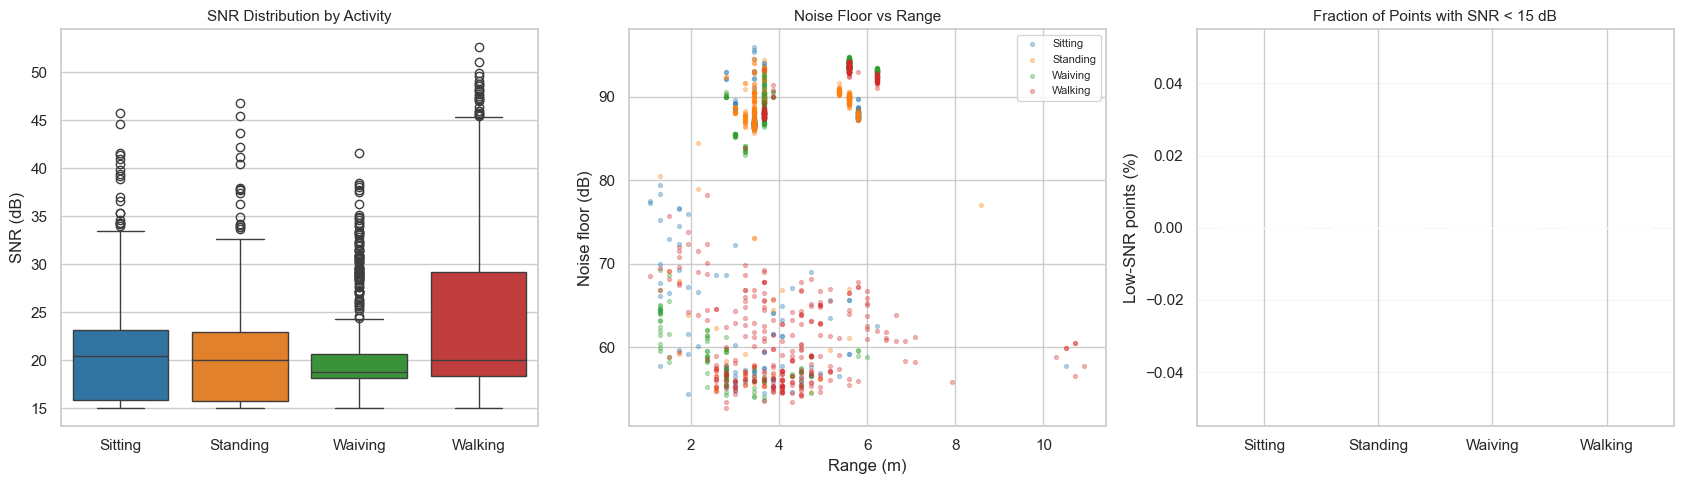


SNR summary by activity (all distances):
           count   mean   std   min   25%   50%   75%   max
activity                                                   
Sitting    351.0  21.26  5.91  15.0  15.9  20.4  23.1  45.8
Standing   433.0  20.19  5.19  15.0  15.8  20.0  22.9  46.8
Waiving    712.0  20.24  4.52  15.0  18.1  18.8  20.6  41.6
Walking   1742.0  23.96  7.96  15.0  18.4  20.0  29.2  52.6


In [10]:
# Merge PC + SNR
all_merged = all_pc.merge(
    all_snr[['activity', 'distance', 'frame_number', 'point_index', 'snr', 'noise']],
    on=['activity', 'distance', 'frame_number', 'point_index'], how='left'
)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# SNR distribution per activity
sns.boxplot(data=all_merged, x='activity', y='snr',
            palette=ACT_PAL, ax=axes[0])
axes[0].set_title('SNR Distribution by Activity', fontsize=11)
axes[0].set_xlabel('')
axes[0].set_ylabel('SNR (dB)')

# Noise floor vs range, coloured by activity
for act in ACTIVITIES:
    act_sub = all_merged[all_merged['activity'] == act]
    sub = act_sub.sample(min(500, len(act_sub)), random_state=42)
    axes[1].scatter(sub['range'], sub['noise'], alpha=0.3, s=8,
                    color=ACT_PAL[act], label=act, rasterized=True)
axes[1].set_title('Noise Floor vs Range', fontsize=11)
axes[1].set_xlabel('Range (m)')
axes[1].set_ylabel('Noise floor (dB)')
axes[1].legend(fontsize=8)

# Low-SNR fraction (< 15 dB threshold) per activity
thresh = 15
low_snr = (all_merged.groupby('activity')
           .apply(lambda g: (g['snr'] < thresh).mean() * 100)
           .reset_index(name='low_snr_pct'))
axes[2].bar(low_snr['activity'], low_snr['low_snr_pct'],
            color=[ACT_PAL[a] for a in low_snr['activity']])
axes[2].set_title(f'Fraction of Points with SNR < {thresh} dB', fontsize=11)
axes[2].set_xlabel('')
axes[2].set_ylabel('Low-SNR points (%)')
axes[2].grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('eda_snr_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nSNR summary by activity (all distances):')
print(all_merged.groupby('activity')['snr'].describe().round(2))

## 7. Per-Frame Feature Engineering & Correlation

In [11]:
def extract_frame_features(pc_df, snr_df):
    """
    Aggregate each frame in pc_df into a single feature vector.
    Returns a DataFrame with one row per frame.
    """
    merged = pc_df.merge(
        snr_df[['activity', 'distance', 'frame_number', 'point_index', 'snr', 'noise']],
        on=['activity', 'distance', 'frame_number', 'point_index'], how='left'
    )

    def agg_frame(g):
        return pd.Series({
            'point_count':    len(g),
            'mean_x':         g['x'].mean(),
            'std_x':          g['x'].std(ddof=0),
            'mean_y':         g['y'].mean(),
            'std_y':          g['y'].std(ddof=0),
            'mean_z':         g['z'].mean(),
            'mean_doppler':   g['doppler'].mean(),
            'std_doppler':    g['doppler'].std(ddof=0),
            'min_doppler':    g['doppler'].min(),
            'max_doppler':    g['doppler'].max(),
            'abs_doppler':    g['doppler'].abs().mean(),
            'mean_range':     g['range'].mean(),
            'std_range':      g['range'].std(ddof=0),
            'mean_snr':       g['snr'].mean(),
            'std_snr':        g['snr'].std(ddof=0),
            'mean_noise':     g['noise'].mean(),
        })

    feat = (merged
            .groupby(['activity', 'distance', 'frame_number'], sort=False)
            .apply(agg_frame)
            .reset_index())
    return feat.fillna(0)

feat_df = extract_frame_features(all_pc, all_snr)
print(f'Feature matrix: {feat_df.shape}')
feat_df.head(3)

Feature matrix: (788, 19)


,activity,distance,frame_number,point_count,mean_x,std_x,mean_y,std_y,mean_z,mean_doppler,std_doppler,min_doppler,max_doppler,abs_doppler,mean_range,std_range,mean_snr,std_snr,mean_noise
0,Sitting,1m,6,5.0,-0.505520,1.755122,3.406314,1.787496,0.0,-0.068907,0.085816,-0.196876,0.000000,0.068907,3.943461,1.607246,18.920000,3.781746,82.160
1,Sitting,1m,7,6.0,0.336794,1.030518,2.855673,1.860622,0.0,-0.147657,0.196876,-0.442971,0.098438,0.180470,2.964740,2.000625,22.816667,6.754361,76.250
2,Sitting,1m,8,4.0,0.008228,1.567921,3.802323,1.783069,0.0,-0.061524,0.106562,-0.246095,0.000000,0.061524,4.072052,1.874521,23.700000,10.247195,85.375


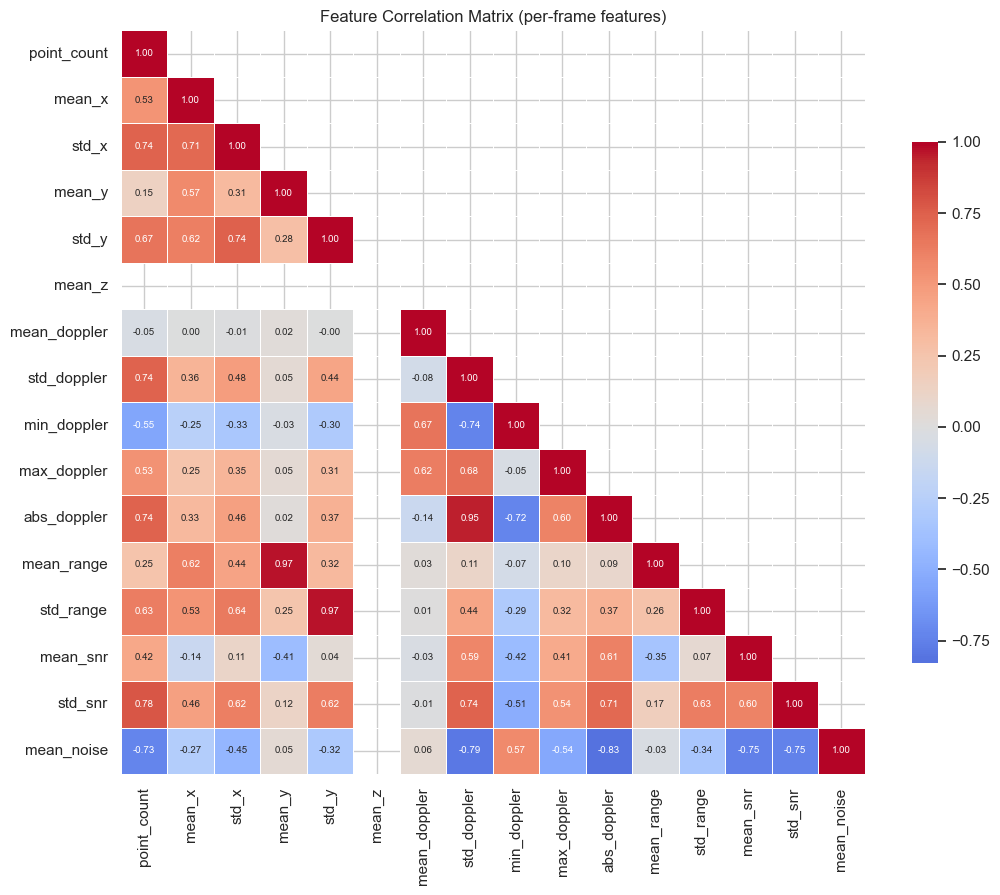

In [12]:
FEATURE_COLS = [
    'point_count', 'mean_x', 'std_x', 'mean_y', 'std_y',
    'mean_z', 'mean_doppler', 'std_doppler', 'min_doppler',
    'max_doppler', 'abs_doppler', 'mean_range', 'std_range',
    'mean_snr', 'std_snr', 'mean_noise'
]

# Correlation heatmap
corr = feat_df[FEATURE_COLS].corr()
fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.4, cbar_kws={'shrink': 0.7},
            ax=ax, annot_kws={'size': 7})
ax.set_title('Feature Correlation Matrix (per-frame features)', fontsize=12)
plt.tight_layout()
plt.savefig('eda_feature_correlation.png', dpi=120, bbox_inches='tight')
plt.show()

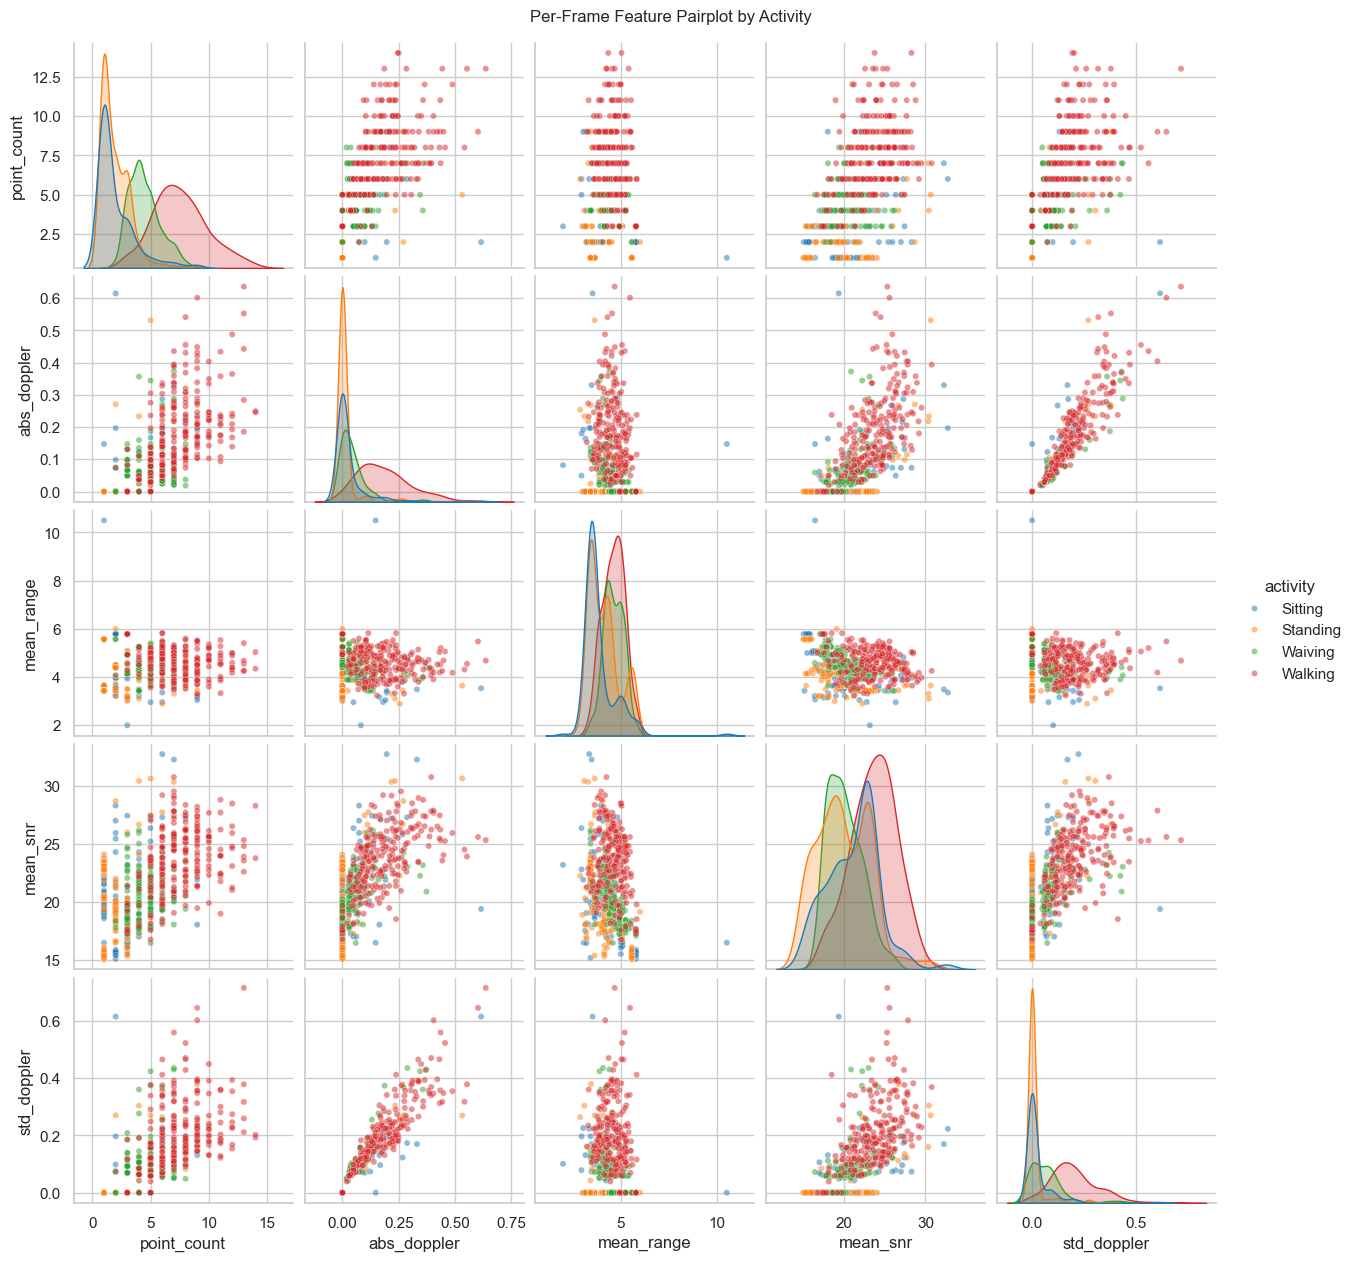

Saved eda_pairplot.png


In [13]:
# Feature distributions per activity — pairplot (subset of features for clarity)
PLOT_FEATS = ['point_count', 'abs_doppler', 'mean_range', 'mean_snr', 'std_doppler']
pair_df = feat_df[['activity'] + PLOT_FEATS]
pg = sns.pairplot(pair_df, hue='activity', palette=ACT_PAL,
                  plot_kws={'alpha': 0.5, 's': 20}, diag_kind='kde')
pg.figure.suptitle('Per-Frame Feature Pairplot by Activity', y=1.01, fontsize=12)
plt.savefig('eda_pairplot.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved eda_pairplot.png')

## 8. PCA & t-SNE Class Separability

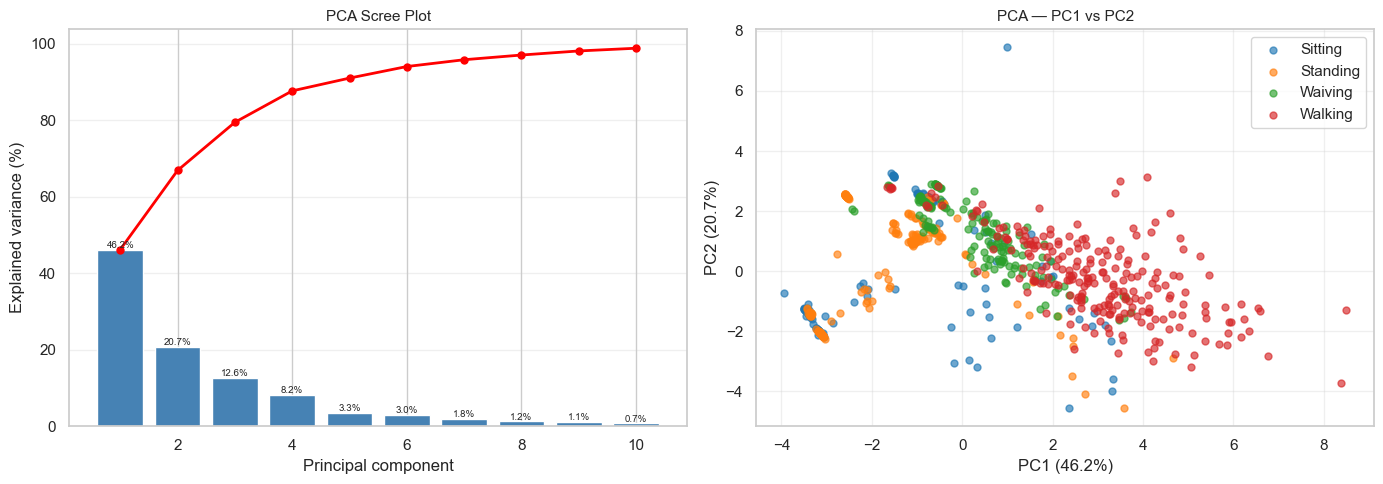

In [ ]:
# -------- PCA Analysis (Final - Your Style) --------

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# -------- Features (FINAL SELECTED) --------
FEATURE_COLS = [
    'point_count',
    'abs_z_diff',
    'std_doppler',
    'mean_snr',
    'mean_noise'
]

# -------- Data --------
X = feat_df[FEATURE_COLS].values.astype(np.float32)
y = feat_df['activity'].values

# -------- Normalize --------
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

# -------- PCA --------
pca = PCA(n_components=len(FEATURE_COLS), random_state=42)
X_pca = pca.fit_transform(X_sc)

# -------- Plot --------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ================= Scree Plot =================
ev_ratio = pca.explained_variance_ratio_
cum_var = np.cumsum(ev_ratio)

axes[0].bar(range(1, len(ev_ratio) + 1), ev_ratio * 100, color='steelblue', label='Individual')
axes[0].plot(range(1, len(ev_ratio) + 1), cum_var * 100,
             'r-o', linewidth=2, markersize=5, label='Cumulative')

axes[0].axhline(90, linestyle='--', linewidth=1)  # 90% threshold

axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('PCA Scree Plot', fontsize=11)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Label bars
for xi, v in enumerate(ev_ratio):
    axes[0].text(xi + 1, v * 100 + 0.8, f'{v*100:.1f}%', ha='center', fontsize=7)

# ================= PCA Scatter =================
for act in ACTIVITIES:
    mask = y == act
    axes[1].scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=act,
        color=ACT_PAL[act],
        alpha=0.65,
        s=25
    )

axes[1].set_xlabel(f'PC1 ({ev_ratio[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({ev_ratio[1]*100:.1f}%)')
axes[1].set_title(f'PCA — PC1 vs PC2 (Total: {cum_var[1]*100:.1f}%)', fontsize=11)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_pca.png', dpi=120, bbox_inches='tight')
plt.show()

Running t-SNE (this may take a moment)...


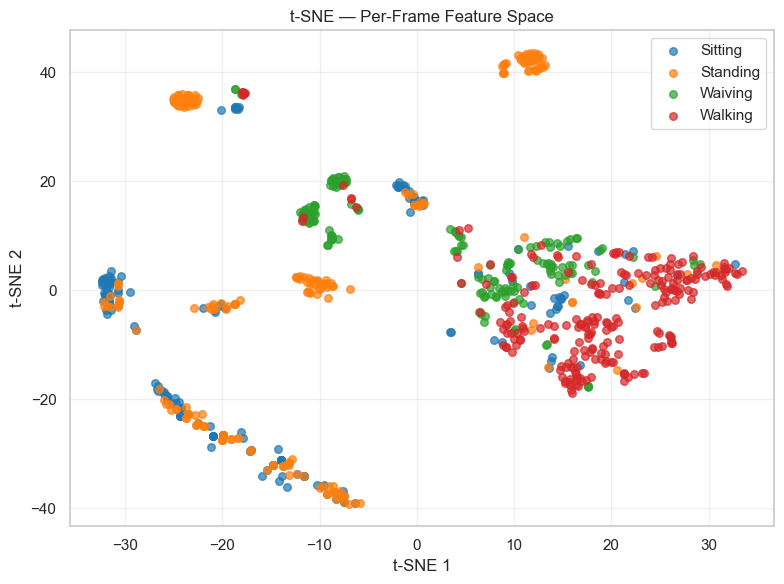

In [15]:
# t-SNE
print('Running t-SNE (this may take a moment)...')
tsne   = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_sc)

fig, ax = plt.subplots(figsize=(8, 6))
for act in ACTIVITIES:
    mask = y == act
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               label=act, color=ACT_PAL[act], alpha=0.7, s=30)
ax.set_title('t-SNE — Per-Frame Feature Space', fontsize=12)
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('eda_tsne.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Cross-Distance Distribution Shift (Train vs Test)

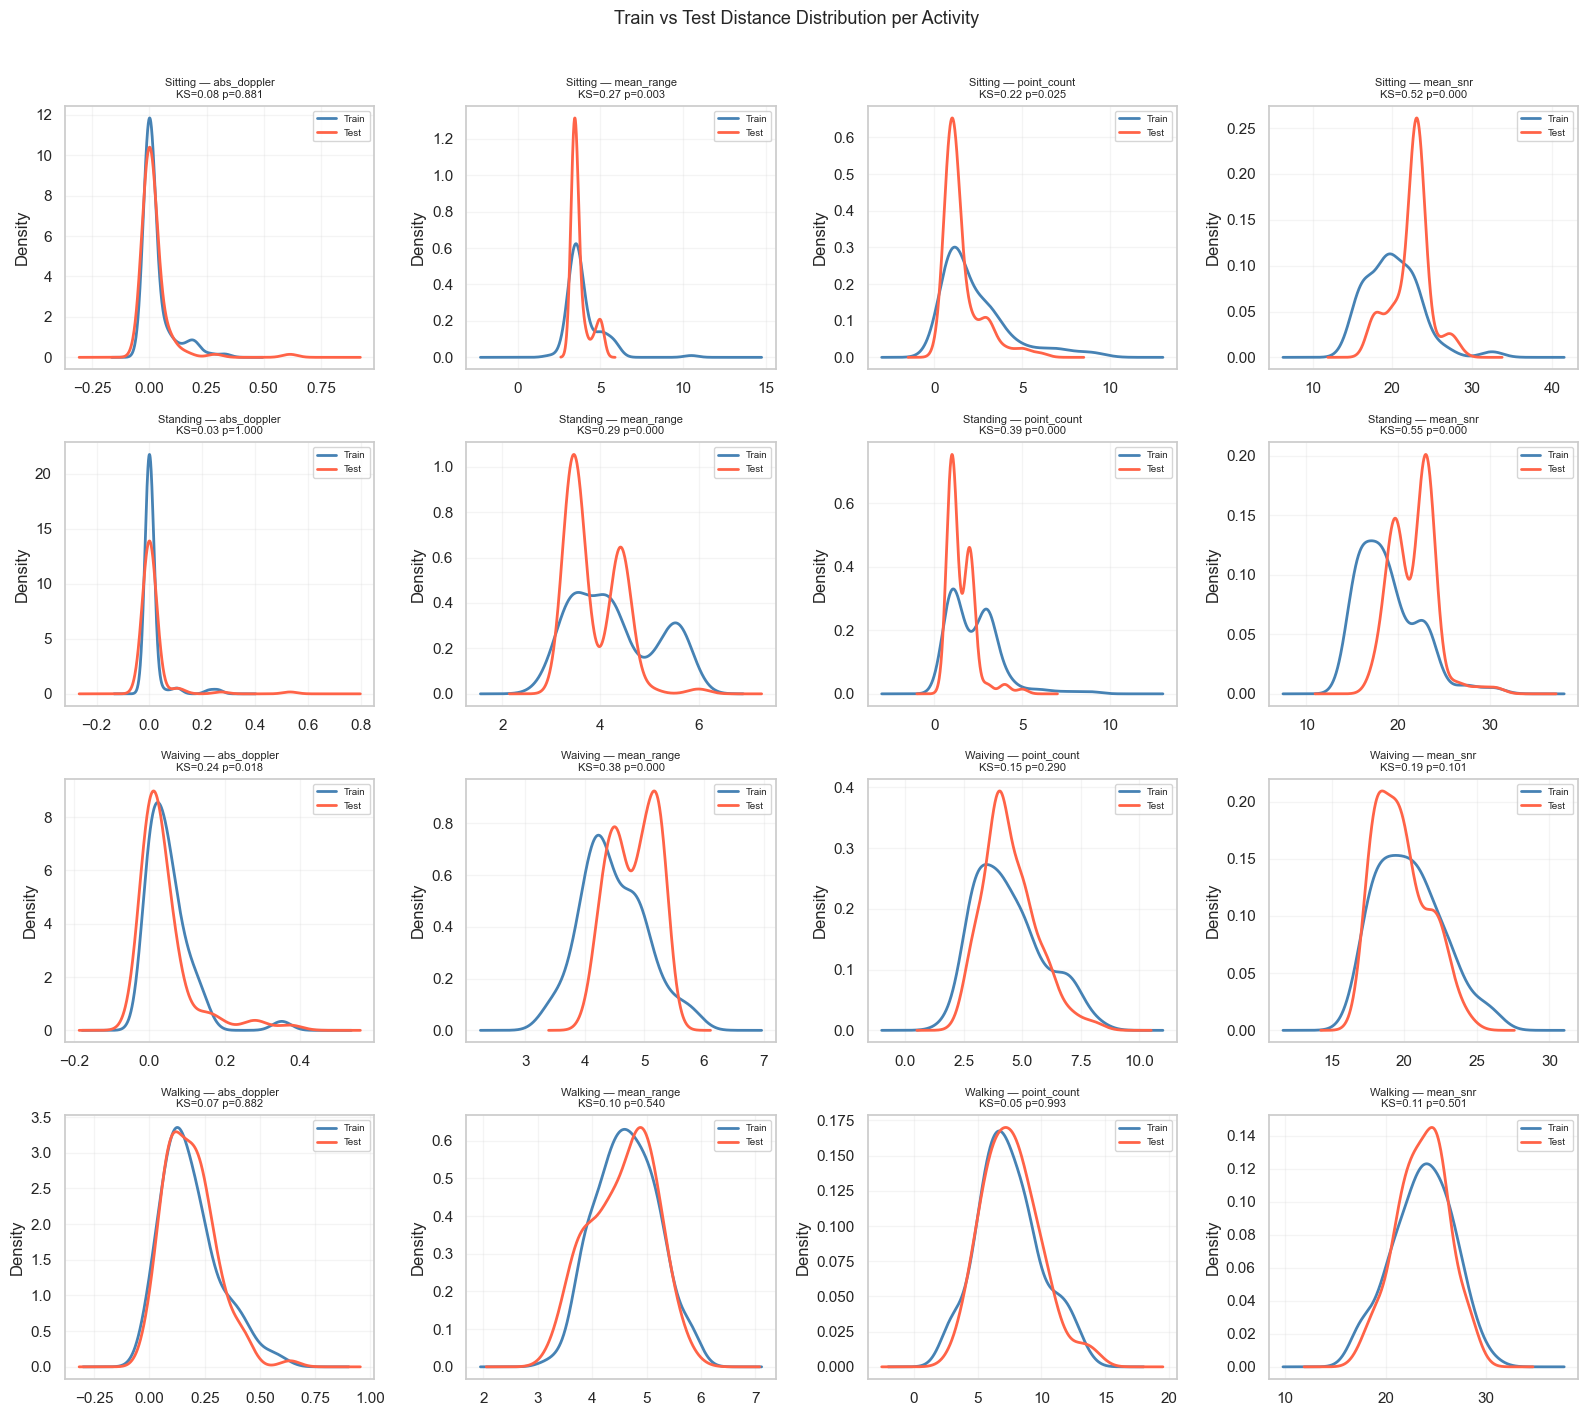


Kolmogorov-Smirnov test (Train vs Test distances):
activity     feature  KS_stat  p_value
 Sitting abs_doppler    0.084   0.8806
 Sitting  mean_range    0.265   0.0032
 Sitting point_count    0.218   0.0253
 Sitting    mean_snr    0.518   0.0000
Standing abs_doppler    0.025   1.0000
Standing  mean_range    0.289   0.0002
Standing point_count    0.386   0.0000
Standing    mean_snr    0.551   0.0000
 Waiving abs_doppler    0.241   0.0177
 Waiving  mean_range    0.379   0.0000
 Waiving point_count    0.152   0.2904
 Waiving    mean_snr    0.191   0.1009
 Walking abs_doppler    0.075   0.8823
 Walking  mean_range    0.103   0.5398
 Walking point_count    0.054   0.9928
 Walking    mean_snr    0.106   0.5014

High KS stat (> 0.3) or low p (< 0.05) → significant distribution shift


In [16]:
# For each activity and feature, compare train-distance vs test-distance distribution
feat_df['split'] = feat_df['distance'].apply(lambda d: 'Train' if d in TRAIN_DISTS else 'Test')

KEY_FEATS = ['abs_doppler', 'mean_range', 'point_count', 'mean_snr']
fig, axes = plt.subplots(len(ACTIVITIES), len(KEY_FEATS),
                         figsize=(4 * len(KEY_FEATS), 3.5 * len(ACTIVITIES)))
fig.suptitle('Train vs Test Distance Distribution per Activity', fontsize=13, y=1.01)

ks_results = []
for r, act in enumerate(ACTIVITIES):
    sub = feat_df[feat_df['activity'] == act]
    for c, feat in enumerate(KEY_FEATS):
        ax = axes[r, c]
        train_v = sub[sub['split'] == 'Train'][feat].dropna()
        test_v  = sub[sub['split'] == 'Test'][feat].dropna()
        train_v.plot.kde(ax=ax, label='Train', color='steelblue', linewidth=2)
        test_v.plot.kde(ax=ax, label='Test',  color='tomato',    linewidth=2)
        ks_stat, ks_p = sp_stats.ks_2samp(train_v, test_v)
        ax.set_title(f'{act} — {feat}\nKS={ks_stat:.2f} p={ks_p:.3f}', fontsize=8)
        ax.set_xlabel('')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.2)
        ks_results.append({'activity': act, 'feature': feat,
                           'KS_stat': round(ks_stat, 3), 'p_value': round(ks_p, 4)})

plt.tight_layout()
plt.savefig('eda_distribution_shift.png', dpi=120, bbox_inches='tight')
plt.show()

ks_df = pd.DataFrame(ks_results)
print('\nKolmogorov-Smirnov test (Train vs Test distances):')
print(ks_df.to_string(index=False))
print('\nHigh KS stat (> 0.3) or low p (< 0.05) → significant distribution shift')

## 10. Outlier & Anomaly Detection

In [17]:
print('=== Outlier Analysis ===\n')

# 1. Dead frames (0 points detected)
all_frame_counts = all_pc.groupby(['activity', 'distance', 'frame_number']).size().reset_index(name='n_pts')
dead = all_frame_counts[all_frame_counts['n_pts'] == 0]
print(f'Dead frames (0 points): {len(dead)}')
if len(dead): print(dead)

# 2. High-density frames (outlier bursts)
q99 = all_frame_counts['n_pts'].quantile(0.99)
spiky = all_frame_counts[all_frame_counts['n_pts'] > q99]
print(f'\nSpiky frames (> 99th pct = {q99:.0f} pts): {len(spiky)}')
if len(spiky): print(spiky.to_string(index=False))

# 3. Near-field noise (range < 0.5 m)
near_field = all_pc[all_pc['range'] < 0.5]
print(f'\nNear-field points (range < 0.5 m): {len(near_field)}')
if len(near_field):
    print(near_field.groupby(['activity', 'distance']).size())

# 4. Doppler outliers (|z-score| > 3 within each recording)
def flag_dop_outliers(df):
    z = np.abs(sp_stats.zscore(df['doppler']))
    return (z > 3).sum()

dop_out = (all_pc.groupby(['activity', 'distance'])
           .apply(flag_dop_outliers)
           .reset_index(name='dop_outlier_count'))
print('\nDoppler outlier (|z| > 3) count per recording:')
print(dop_out.to_string(index=False))

=== Outlier Analysis ===

Dead frames (0 points): 0

Spiky frames (> 99th pct = 12 pts): 7
activity distance  frame_number  n_pts
 Walking       1m           701     13
 Walking       1m           721     13
 Walking       2m           744     13
 Walking       3m           817     13
 Walking       3m           822     14
 Walking      4.m           871     13
 Walking      4.m           903     14

Near-field points (range < 0.5 m): 0

Doppler outlier (|z| > 3) count per recording:
activity distance  dop_outlier_count
 Sitting       1m                  2
 Sitting      2.5                  1
 Sitting       2m                  2
 Sitting       3m                  1
 Sitting      4.m                  2
Standing       1m                  3
Standing      2.5                  2
Standing       2m                  4
Standing       3m                  4
Standing      4.m                  1
 Waiving       1m                  2
 Waiving      2.5                  7
 Waiving       2m             

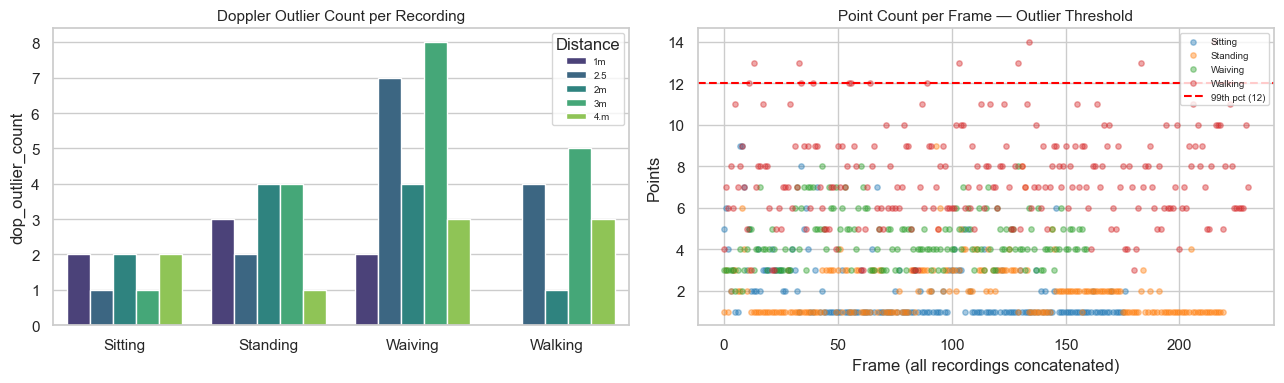

In [18]:
# Visualise outlier magnitude
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(data=dop_out, x='activity', y='dop_outlier_count',
            hue='distance', ax=axes[0], palette='viridis')
axes[0].set_title('Doppler Outlier Count per Recording', fontsize=11)
axes[0].set_xlabel('')
axes[0].legend(title='Distance', fontsize=7)

# Points per frame — outlier frame highlight
for act in ACTIVITIES:
    sub = all_frame_counts[all_frame_counts['activity'] == act]
    axes[1].scatter(range(len(sub)), sub['n_pts'].values,
                    alpha=0.4, s=15, label=act, color=ACT_PAL[act])
axes[1].axhline(q99, color='red', linewidth=1.5, linestyle='--', label=f'99th pct ({q99:.0f})')
axes[1].set_title('Point Count per Frame — Outlier Threshold', fontsize=11)
axes[1].set_xlabel('Frame (all recordings concatenated)')
axes[1].set_ylabel('Points')
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.savefig('eda_outliers.png', dpi=120, bbox_inches='tight')
plt.show()

## 11. Summary — Key EDA Findings

In [19]:
print('='*65)
print('KEY EDA FINDINGS')
print('='*65)

print('\n1. FRAME COUNTS')
fc = inventory.groupby('Activity')['PC frames'].agg(['min','max','mean'])
print(fc.round(1).to_string())

print('\n2. POINTS PER FRAME')
pf = ppf_df.groupby('activity')['pts_per_frame'].agg(['min','max','mean','median'])
print(pf.round(2).to_string())

print('\n3. DOPPLER RANGES BY CLASS')
dr = all_pc.groupby('activity')['doppler'].agg(
    min_dop='min', max_dop='max', mean_dop='mean', abs_mean=lambda x: x.abs().mean()
)
print(dr.round(3).to_string())

print('\n4. SNR MEDIANS BY CLASS')
sm = all_merged.groupby('activity')['snr'].median()
print(sm.round(1).to_string())

print('\n5. TRAINING DATA SIZE')
train_frames = inventory[inventory['Split'] == 'Train'].groupby('Activity')['PC frames'].sum()
test_frames  = inventory[inventory['Split'] == 'Test' ].groupby('Activity')['PC frames'].sum()
print('Train frames per activity:', train_frames.to_dict())
print('Test  frames per activity:', test_frames.to_dict())

print('\n6. RECOMMENDATIONS FOR LSTM TRAINING')
print('  - Use per-frame point-cloud features (16-dim) as LSTM input')
print('  - Apply sliding window (W=20 frames, stride=5) for data augmentation')
print('  - Normalize each feature with StandardScaler fit on train set')
print('  - Watch for class imbalance across distances (check KS results above)')
print('  - Consider SNR-based filtering: discard points with SNR < 10 dB')
print('='*65)

KEY EDA FINDINGS

1. FRAME COUNTS
          min  max  mean
Activity                
Sitting    26   41  35.4
Standing   42   48  44.0
Waiving    30   36  32.0
Walking    36   54  46.2

2. POINTS PER FRAME
          min  max  mean  median
activity                        
Sitting     1    9  1.98     1.0
Standing    1    9  1.97     2.0
Waiving     2    8  4.45     4.0
Walking     3   14  7.54     7.0

3. DOPPLER RANGES BY CLASS
          min_dop  max_dop  mean_dop  abs_mean
activity                                      
Sitting    -1.230    0.541     0.012     0.061
Standing   -0.738    0.738    -0.005     0.031
Waiving    -0.935    0.984     0.003     0.051
Walking    -2.264    2.018    -0.017     0.205

4. SNR MEDIANS BY CLASS
activity
Sitting     20.4
Standing    20.0
Waiving     18.8
Walking     20.0

5. TRAINING DATA SIZE
Train frames per activity: {'Sitting': 96, 'Standing': 133, 'Waiving': 94, 'Walking': 126}
Test  frames per activity: {'Sitting': 81, 'Standing': 87, 'Waiving': 6